In [292]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import torchinfo
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torchvision.utils as vutils
from collections import Counter
from tqdm.auto import tqdm
import copy
import random


import torchmetrics

import helper_utils


In [293]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: CUDA


## Hyperparameters

In [1]:
BATCH_SIZE = 32
LEARNING_RATE = 0.005
LEARNING_RATE_S = 0.001
NUM_EPOCHS = 15

## Datasets and DataLoaders

### Dataset Transforms

In [295]:
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3)
])

val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3)
])

### Train, Test and Validation Datasets and DataLoaders

In [296]:
train_dir = os.path.join("data", "train")
test_dir = os.path.join("data", "test")
val_dir = os.path.join("data", "validation")

train_dataset = ImageFolder(root = train_dir, transform = train_transforms)
val_dataset = ImageFolder(root = val_dir, transform = val_transforms)
test_dataset = ImageFolder(root = test_dir, transform = val_transforms)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False)

In [297]:
classes = train_dataset.classes

num_classes = len(classes)

print(f"Classes: {classes}")
print(f"Number of classes: {num_classes}")

Classes: ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']
Number of classes: 10


In [298]:
class InvertedResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expansion_factor, shortcut = None):
        super(InvertedResidualBlock, self).__init__()

        hidden_dim = in_channels * expansion_factor



        # 1 x 1 pointwise convolution to expand the number of channels
        self.expand = nn.Sequential(
            nn.Conv2d(in_channels =  in_channels,
                      out_channels = hidden_dim,
                      kernel_size = 1, 
                      bias = False
                      ),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace = True)
        )

        # 3 x 3 depthwise convolution
        self.depthwise = nn.Sequential(
            nn.Conv2d(in_channels = hidden_dim,
                      out_channels = hidden_dim,
                      kernel_size = 3,
                      stride = stride,
                      padding = 1,
                      bias = False,
                      groups = hidden_dim
                      ),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace = True)
        )

        # 1 x 1 pointwise convolution to project back to the original number of channels
        # Bottleneck
        self.project = nn.Sequential(
            nn.Conv2d(in_channels = hidden_dim,
                      out_channels = out_channels,
                      kernel_size = 1,
                      bias = False),
            nn.BatchNorm2d(out_channels)
        )

        # Optional shortcut connection for residual learning
        self.shortcut = shortcut



    def forward(self, x):

        skip = x

        out = self.expand(x)
        out = self.depthwise(out)
        out = self.project(out)
        
        if self.shortcut is not None:
            skip = self.shortcut(x)

        if skip.shape == out.shape:
            out = out + skip

        return F.relu(out)



In [299]:
class MobileNetBackbone(nn.Module):
    def __init__(self):

        super(MobileNetBackbone, self).__init__()


        self.stem = nn.Sequential(
           nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3,stride = 2, padding = 1, bias = False),
           nn.BatchNorm2d(16),
           nn.ReLU(inplace = True)
        )

        self.blocks = nn.Sequential(
            self._make_block(in_channels = 16, out_channels = 24, stride = 2, expansion_factor = 6),
            self._make_block(in_channels = 24, out_channels = 32, stride = 2, expansion_factor = 6),
            self._make_block(in_channels = 32, out_channels = 64, stride = 2, expansion_factor = 12),
            self._make_block(in_channels = 64, out_channels = 128, stride = 2, expansion_factor = 12),
        )





    def _make_block(self, in_channels, out_channels, stride, expansion_factor):

        condition = (stride !=1) or (in_channels != out_channels)

        if condition:
            shortcut = nn.Sequential(
                nn.Conv2d(in_channels = in_channels,
                          out_channels = out_channels,
                          kernel_size = 1,
                          stride = stride,
                          padding = 0,
                          bias = False),
                nn.BatchNorm2d(out_channels)
            )

        else:
            shortcut = None


        block = InvertedResidualBlock(
            in_channels = in_channels,
            out_channels = out_channels,
            stride = stride,
            expansion_factor = expansion_factor,
            shortcut = shortcut
        )

        return block

    def forward(self, x):
        x = self.stem(x)

        x = self.blocks(x)

        return x


In [300]:
# --- Verification ---
# Define parameters for verification
batch_size=32
img_size = 64 # Input image height/width
depth = 3 # Summary depth

# Instantiate the backbone
backbone = MobileNetBackbone()

# Define the input tensor shape
input_size = (batch_size, 3, img_size, img_size)

# Configuration for torchinfo summary
config = {
    "input_size": input_size,
    "attr_names": ["input_size", "output_size", "num_params"],
    "col_names_display": ["Input Shape ", "Output Shape", "Param #"],
    "depth": depth
}

# Generate the summary
summary = torchinfo.summary(
    model=backbone,
    input_size=config["input_size"],
    col_names=config["attr_names"],
    depth=config["depth"]
)

# Display the formatted summary
print("--- Backbone Summary ---\n")
helper_utils.display_torch_summary(summary, config["attr_names"], config["col_names_display"], config["depth"])

--- Backbone Summary ---



Layer (type (var_name):depth-idx),Input Shape,Output Shape,Param #
MobileNetBackbone (MobileNetBackbone),"[32, 3, 64, 64]","[32, 128, 2, 2]",--
Sequential (stem): 1-1,"[32, 3, 64, 64]","[32, 16, 32, 32]",--
Conv2d (0): 2-1,"[32, 3, 64, 64]","[32, 16, 32, 32]",432
BatchNorm2d (1): 2-2,"[32, 16, 32, 32]","[32, 16, 32, 32]",32
ReLU (2): 2-3,"[32, 16, 32, 32]","[32, 16, 32, 32]",--
Sequential (blocks): 1-2,"[32, 16, 32, 32]","[32, 128, 2, 2]",--
InvertedResidualBlock (0): 2-4,"[32, 16, 32, 32]","[32, 24, 16, 16]",--
Sequential (expand): 3-1,"[32, 16, 32, 32]","[32, 96, 32, 32]","1,728"
Sequential (depthwise): 3-2,"[32, 96, 32, 32]","[32, 96, 16, 16]","1,056"
Sequential (project): 3-3,"[32, 96, 16, 16]","[32, 24, 16, 16]","2,352"


In [301]:
class MobileNetLikeClassifier(nn.Module):
    def __init__(self, num_classes):

        super(MobileNetLikeClassifier, self).__init__()

        self.backbone = MobileNetBackbone()

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )


    def forward(self, x):
        x = self.backbone(x)

        x = self.head(x)

        return x

In [302]:
mobilenet_classifier = MobileNetLikeClassifier(num_classes=num_classes)

In [303]:
# Define parameters for verification
batch_size=32
img_size = 64 # Input image height/width
depth = 3 # Summary depth   

# Define the input tensor shape
input_size = (batch_size, 3, img_size, img_size)

# Configuration for torchinfo summary
config = {
    "input_size": input_size,
    "attr_names": ["input_size", "output_size", "num_params"],
    "col_names_display": ["Input Shape ", "Output Shape", "Param #"],
    "depth": depth # Show layers up to 3 levels deep for detail
}

# Generate the summary for the complete classifier
summary = torchinfo.summary(
    model=mobilenet_classifier,
    input_size=config["input_size"],
    col_names=config["attr_names"],
    depth=config["depth"]
)

# Display the formatted summary
print("--- Classifier Summary ---\n")
helper_utils.display_torch_summary(summary, config["attr_names"], config["col_names_display"], config["depth"])

--- Classifier Summary ---



Layer (type (var_name):depth-idx),Input Shape,Output Shape,Param #
MobileNetLikeClassifier (MobileNetLikeClassifier),"[32, 3, 64, 64]","[32, 10]",--
MobileNetBackbone (backbone): 1-1,"[32, 3, 64, 64]","[32, 128, 2, 2]",--
Sequential (stem): 2-1,"[32, 3, 64, 64]","[32, 16, 32, 32]",--
Conv2d (0): 3-1,"[32, 3, 64, 64]","[32, 16, 32, 32]",432
BatchNorm2d (1): 3-2,"[32, 16, 32, 32]","[32, 16, 32, 32]",32
ReLU (2): 3-3,"[32, 16, 32, 32]","[32, 16, 32, 32]",--
Sequential (blocks): 2-2,"[32, 16, 32, 32]","[32, 128, 2, 2]",--
InvertedResidualBlock (0): 3-4,"[32, 16, 32, 32]","[32, 24, 16, 16]","5,568"
InvertedResidualBlock (1): 3-5,"[32, 24, 16, 16]","[32, 32, 8, 8]","10,832"
InvertedResidualBlock (2): 3-6,"[32, 32, 8, 8]","[32, 64, 4, 4]","44,160"


In [304]:
# Function to compute class weights for the dataset
# Class weights will be used to handle data imbalance

def compute_class_weight(dataset):
    labels = dataset.targets


    class_counts = Counter(labels)

    # Class counts need to be sorted by class index because Counter does not guarantee order in terms of classes
    sorted_counts = [class_counts[i] for i in sorted(class_counts)]

    total_samples = len(labels)

    num_classes = len(class_counts)


    class_weights = []
    
    for count in sorted_counts:
        weight = total_samples / (num_classes * count)
        class_weights.append(weight)

    weights_tensor = torch.tensor(class_weights, dtype = torch.float)

    return weights_tensor

class_weights = compute_class_weight(train_dataset)
class_weights = class_weights.to(device)

In [305]:
loss_function = nn.CrossEntropyLoss(weight = class_weights)

# Print computed class weights
for i, weight in enumerate(class_weights):

    print(f'Class {classes[i]} weight: {weight}')

Class dress weight: 1.273029088973999
Class hat weight: 2.4943089485168457
Class longsleeve weight: 0.6742857098579407
Class outwear weight: 1.667391300201416
Class pants weight: 0.6555555462837219
Class shirt weight: 1.0579310655593872
Class shoes weight: 1.549494981765747
Class shorts weight: 1.518811821937561
Class skirt weight: 2.739285707473755
Class t-shirt weight: 0.3859119415283203


In [306]:
optimizer = torch.optim.Adam(mobilenet_classifier.parameters(),lr = LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer = optimizer, step_size = 5, gamma = 0.1)

## Training Loop

In [307]:
mobilenet_classifier.to(device)
num_classes = len(classes)


# Training and Validation Accuracy Metrics
train_acc_metric = torchmetrics.Accuracy(task = 'multiclass', num_classes = num_classes).to(device)
val_acc_metric = torchmetrics.Accuracy(task = 'multiclass', num_classes = num_classes).to(device)

best_val_acc = 0.0

best_epoch = 0

model_best_state = None

for epoch in range(NUM_EPOCHS):

    mobilenet_classifier.train()

    running_train_loss = 0.0

    train_acc_metric.reset()

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]", leave=False)

    for i, data in enumerate(train_pbar):

        inputs, labels = data

        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = mobilenet_classifier(inputs)

        loss = loss_function(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

        preds = torch.argmax(outputs, 1)

        train_acc_metric.update(preds, labels)

        train_pbar.set_postfix(batch_loss=loss.item())

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    epoch_train_acc = train_acc_metric.compute().item()



    mobilenet_classifier.eval()

    running_val_loss = 0.0

    val_acc_metric.reset()

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [VAL]", leave=False)

    with torch.no_grad():

        for images, labels in val_pbar:

            images, labels = images.to(device), labels.to(device)

            outputs = mobilenet_classifier(images)

            loss = loss_function(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, 1)

            val_acc_metric.update(preds, labels)

            val_pbar.set_postfix(batch_loss=loss.item())

        epoch_val_loss = running_val_loss / len(val_loader.dataset)

        epoch_val_acc = val_acc_metric.compute().item()


        # Step the scheduler
        if scheduler is not None:
            # Check if it's ReduceLROnPlateau, which needs a metric
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                # Step the scheduler based on validation loss
                scheduler.step(epoch_val_loss)
            else:
                # Step other types of schedulers
                scheduler.step()
        
        # Log metrics for the epoch
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")
        
        # --- Check for Best Model ---
        # If current validation accuracy is better than the best seen so far
        if epoch_val_acc > best_val_acc:
            # Update the best validation accuracy
            best_val_acc = epoch_val_acc
            # Store the current epoch number
            best_epoch = epoch + 1
            # Use copy.deepcopy to save a snapshot of the model's state
            best_model_state = copy.deepcopy(mobilenet_classifier.state_dict())
            # Print a message indicating a new best model
            print(f"    ^ New best model found!")
        # --- End Check ---

    print("\n--- Training Complete ---")
    
    # --- Load Best Model ---
    # Check if a best model state was saved
    if best_model_state is not None:
        print(f"\nReturning best model from epoch {best_epoch} with {best_val_acc:.4f} validation accuracy.")
        # Load the best performing weights back into the model
        mobilenet_classifier.load_state_dict(best_model_state)
    else:
        # Warn if no improvement was seen and the last model is being returned
        print("\nWarning: No best model state was saved (e.g., validation never improved). Returning last model.")

Epoch 1/15 [TRAIN]:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 1/15 [VAL]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/15 | Train Loss: 2.0398, Train Acc: 0.2797 | Val Loss: 1.9155, Val Acc: 0.3284
    ^ New best model found!

--- Training Complete ---

Returning best model from epoch 1 with 0.3284 validation accuracy.


Epoch 2/15 [TRAIN]:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 2/15 [VAL]:   0%|          | 0/11 [00:00<?, ?it/s]

...

Epoch 14/15 [VAL]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.6889, Train Acc: 0.7836 | Val Loss: 1.0334, Val Acc: 0.6628
    ^ New best model found!

--- Training Complete ---

Returning best model from epoch 14 with 0.6628 validation accuracy.


Epoch 15/15 [TRAIN]:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 15/15 [VAL]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.6789, Train Acc: 0.7761 | Val Loss: 1.0139, Val Acc: 0.6686
    ^ New best model found!

--- Training Complete ---

Returning best model from epoch 15 with 0.6686 validation accuracy.


# SIAMESE NETWORK

In [308]:
class TripleDataset(Dataset):
    def __init__(self, dataset):

        self.dataset = dataset

        self.labels = dataset.targets



    def __len__(self):
        return len(self.dataset)



    # Store the index of every image that belongs to a particular class in a dictionary sorted by labels
    def _labels_to_indices(self):

        labels_to_indices = {}

        for idx, (_, label) in enumerate(self.dataset):

            if label not in labels_to_indices:
                labels_to_indices[label] = []

            labels_to_indices[label].append(idx) 

        return labels_to_indices

    def _get_positive_negative_indices(self, anchor_idx, anchor_label):

        labels_to_indices = self._labels_to_indices()

        positive_idx = random.choice([idx for idx in labels_to_indices[anchor_label] if idx != anchor_idx])

        negative_label = random.choice([label for label in self.labels if label != anchor_label])

        negative_idx = random.choice(labels_to_indices[negative_label])

        return positive_idx, negative_idx
    
    def __getitem__(self, index):
        
        
        anchor_img, anchor_label = self.dataset[index]

        positive_idx, negative_idx = self._get_positive_negative_indices(index, anchor_label)

        positive_img, _ = self.dataset[positive_idx]
        negative_img, _ = self.dataset[negative_idx] 

        return (anchor_img, positive_img, negative_img)



Sample Triplet (Anchor, Positive, Negative):


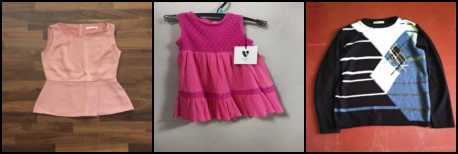

In [309]:
random.seed(42)

# Create a copy of the validation dataset to use as a base for the toy triplet dataset
toy_dataset_base = copy.deepcopy(val_dataset)

toy_dataset_base.transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

triple_dataset_toy = TripleDataset(dataset = toy_dataset_base)

anchor_img, positive_image, negative_image = triple_dataset_toy[0]

# Display the triplet
images_list = [anchor_img, positive_image, negative_image]
grid = vutils.make_grid(images_list, nrow = 3, padding = 2) 
grid_pil = transforms.ToPILImage()(grid)
print("Sample Triplet (Anchor, Positive, Negative):")
display(grid_pil)

In [310]:
triple_dataset = TripleDataset(train_dataset)

siamese_dataloader = torch.utils.data.DataLoader(
    triple_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
)

In [311]:
class SiameseEncoder(nn.Module):

    def __init__(self, backbone):
        super(SiameseEncoder, self).__init__()

        self.backbone = backbone

        self.representation = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

    
    def forward(self, x):
        features = self.backbone(x)

        representation = self.representation(features)

        return representation

In [312]:
siamese_encoder = SiameseEncoder(backbone = mobilenet_classifier.backbone)

In [ ]:
class SiameseNetwork(nn.Module):

    def __init__(self, embedding_network):
        super(SiameseEncoder, self).__init__()


        self.embedding_network = embedding_network




    def forward(self, anchor, positive, negative):
        anchor_output = self.embedding_network(anchor)

        positive_output = self.embedding_network(positive)

        negative_output = self.embedding_network(negative)

        return anchor_output, positive_output, negative_output
    


    def _get_embedding(self, image):
        return self.embedding_network(image)

In [ ]:
siamese_network = SiameseNetwork(embedding_network=siamese_encoder)

In [ ]:
loss_function = nn.TripletMarginLoss(margin = 1.0, p = 2)

optimizer = torch.optim.AdamW(params = siamese_network.parameters(), lr = LEARNING_RATE_S)

In [ ]:
def SiameseTrainingLoop(model, dataloader, loss_function, optimizer, device, num_epochs)